## Assignment 4

<br>

### Question 1
Investigate the model for predicting Diabetes disease progression by adding more explanatory variables to it in addition to `bmi` and `s5`.

a) Which variable would you add next? Why?

b) How does adding it affect the model's performance? Compute metrics and compare to having just `bmi` and `s5`.

d) Does it help if you add even more variables?

Include your own findings and explanations in code comments or inside triple quotes """...""".

In [137]:
import pandas as pd
import numpy as np
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

diabetes = load_diabetes(as_frame=True)
df = diabetes.frame

print(df.head())

        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


In [138]:
correlations = df.corr()['target'].sort_values(ascending=False)
print(correlations)

target    1.000000
bmi       0.586450
s5        0.565883
bp        0.441482
s4        0.430453
s6        0.382483
s1        0.212022
age       0.187889
s2        0.174054
sex       0.043062
s3       -0.394789
Name: target, dtype: float64


In [139]:
y = df['target']
x1 = df[['bmi', 's5']]
model1 = LinearRegression()
model1.fit(x1, y)

y_pred1 = model1.predict(x1)
r2_m1 = r2_score(y, y_pred1)
mse_m1 = mean_squared_error(y, y_pred1)

print('bmi + s5')
print(f"R2 Score: {r2_m1:.4f}")
print(f"MSE: {mse_m1:.4f}")

bmi + s5
R2 Score: 0.4595
MSE: 3205.1901


In [140]:
y = df['target']
chosen_variable = 'bp'
x2 = df[['bmi', 's5', chosen_variable]]
model2 = LinearRegression()
model2.fit(x2, y)

y_pred2 = model2.predict(x2)
r2_m2 = r2_score(y, y_pred2)
mse_m2 = mean_squared_error(y, y_pred2)

print(f"bmi + s5 + {chosen_variable}")
print(f"R2 Score: {r2_m2:.4f}")
print(f"MSE: {mse_m2:.4f}")

bmi + s5 + bp
R2 Score: 0.4801
MSE: 3083.0513


Summarization Question (1)
* a) The next variable add is bp, because it has the highest Correlation with the target.
* b) After adding bp improves the model's performance:
The R-squared score increased from **0.4595** to **0.4801**.
The MSE decreased from **3205.1901** to **3083.0513**.
* d) To adding too many variables might increase the R-squared score,but it is risky. It can cause overfitting.

### Question 2

Consider the dataset `50_Startups.csv` which contains data for companies' profit etc.

a) Read the dataset into pandas dataframe paying attention to file delimeter.

b) Identify the variables inside the dataset

c) Investigate the correlation between the variables

d) Choose appropriate variables to predict company profit. Justify your choice.

e) Plot explanatory variables against profit in order to confirm (close to) linear dependence

f) Form training and testing data (80/20 split)

g) Train linear regression model with training data

h) Compute RMSE and $R^2$ values for training and testing data separately

Include your own findings and explanations in code comments or inside triple quotes """...""".

Answer A > Import CSV file

In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

df = pd.read_csv('50_Startups.csv')

Answer B > Show the dataset and top 5 data header

In [142]:
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   R&D Spend        50 non-null     float64
 1   Administration   50 non-null     float64
 2   Marketing Spend  50 non-null     float64
 3   State            50 non-null     str    
 4   Profit           50 non-null     float64
dtypes: float64(4), str(1)
memory usage: 2.1 KB
None
   R&D Spend  Administration  Marketing Spend       State     Profit
0  165349.20       136897.80        471784.10    New York  192261.83
1  162597.70       151377.59        443898.53  California  191792.06
2  153441.51       101145.55        407934.54     Florida  191050.39
3  144372.41       118671.85        383199.62    New York  182901.99
4  142107.34        91391.77        366168.42     Florida  166187.94


Answer C > The correlation between variables


                 R&D Spend  Administration  Marketing Spend    Profit
R&D Spend         1.000000        0.241955         0.724248  0.972900
Administration    0.241955        1.000000        -0.032154  0.200717
Marketing Spend   0.724248       -0.032154         1.000000  0.747766
Profit            0.972900        0.200717         0.747766  1.000000


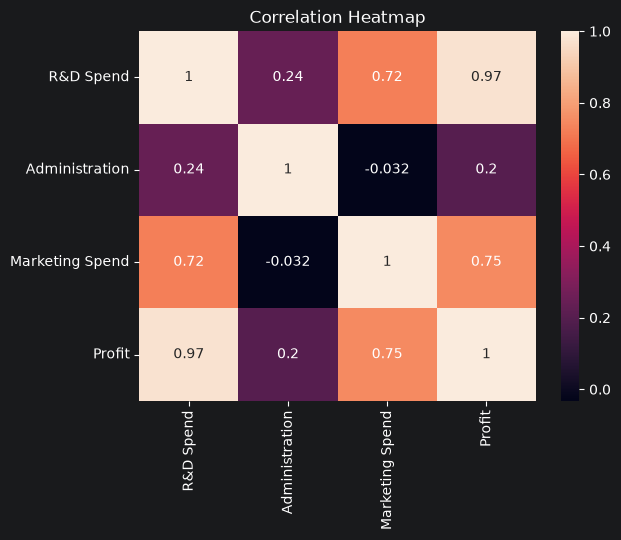

In [143]:
numeric_cols = df.select_dtypes(include=np.number)
corr_matrix = numeric_cols.corr()
print(corr_matrix)

sns.heatmap(corr_matrix,annot=True)
plt.title("Correlation Heatmap")
plt.show()

Answer D > Choose appropriate variables to predict

In [144]:
X = df[['R&D Spend', 'Marketing Spend']]
y = df['Profit']

Answer E > Plot explanatory variables

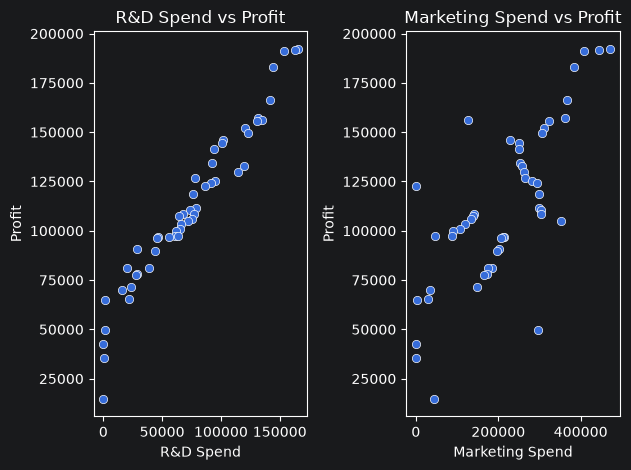

In [145]:
plt.subplot(1,2,1)
sns.scatterplot(x=df['R&D Spend'],y=df['Profit'])
plt.title("R&D Spend vs Profit")

plt.subplot(1,2,2)
sns.scatterplot(x=df['Marketing Spend'],y=df['Profit'])
plt.title("Marketing Spend vs Profit")

plt.tight_layout()
plt.show()

Answer F > Training and Testing data

In [146]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

Answer G > Train linear regression model

In [147]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](2,)","[0.78,0.04]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](2,)","['R&D Spend','Marketing Spend']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,4.554e+04
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,2
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int,2


Answer H > Compute for train and test data

In [148]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
train_r2 = r2_score(y_train, y_train_pred)

test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
test_r2 = r2_score(y_test, y_test_pred)

print(f"Training - RMSE: {train_rmse:.4f}, R score: {train_r2:.4f}")
print(f"Testing  - RMSE: {test_rmse:.4f}, R score: {test_r2:.4f}")

Training - RMSE: 9101.1915, R score: 0.9519
Testing  - RMSE: 8206.3288, R score: 0.9168


### Question 3

Consider car performance data from the file `Auto.csv`.

a) Read the data into pandas dataframe

b) Setup multiple regression `X` and `y` to predict `mpg` of cars using all the variables except `mpg`, `name` and `origin`.

c) Split data into training and testing sets (80/20 split)

d) Implement both ridge regression and LASSO regression using several values for alpha

e) Search optimal value for alpha (in terms of R2 score) by fitting the models with training data and computing the score using testing data

f) Plot the R2 scores for both regressors as functions of alpha

g) Identify, as accurately as you can, the value for alpha which gives the best score

 
Include your own findings and explanations in code comments or inside triple quotes """...""".

Answer A > Import CSV into pandas dataframe

In [149]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

df = pd.read_csv('Auto.csv', na_values="?")
df = df.dropna()
print(df.info())
print(df.head())

<class 'pandas.DataFrame'>
Index: 392 entries, 0 to 396
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           392 non-null    float64
 1   cylinders     392 non-null    int64  
 2   displacement  392 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        392 non-null    int64  
 5   acceleration  392 non-null    float64
 6   year          392 non-null    int64  
 7   origin        392 non-null    int64  
 8   name          392 non-null    str    
dtypes: float64(4), int64(4), str(1)
memory usage: 30.6 KB
None
    mpg  cylinders  displacement  horsepower  weight  acceleration  year  \
0  18.0          8         307.0       130.0    3504          12.0    70   
1  15.0          8         350.0       165.0    3693          11.5    70   
2  18.0          8         318.0       150.0    3436          11.0    70   
3  16.0          8         304.0       150.0    3433          12.0    7

Answer B > Select X and Select Y

In [150]:
X = df.drop(columns=['mpg', 'name', 'origin'])
y = df['mpg']

Answer C > Train and Test 80/20

In [151]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [152]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [153]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)
lr_r2 = r2_score(y_test, y_pred_lr)

print("Linear Regression R square =", round(lr_r2, 4))

Linear Regression R square = 0.7942


Answer D > Ridge and Lasso several alpha values

In [155]:
alphas = np.logspace(-4, 2, 100)

ridge_scores = [
    Ridge(alpha=a)
    .fit(X_train_scaled, y_train)
    .score(X_test_scaled, y_test)
    for a in alphas
]

lasso_scores = [
    Lasso(alpha=a, max_iter=10000)
    .fit(X_train_scaled, y_train)
    .score(X_test_scaled, y_test)
    for a in alphas
]

Answer E > Fine optimal alpha

In [156]:
best_ridge_idx = np.argmax(ridge_scores)
best_lasso_idx = np.argmax(lasso_scores)

best_ridge_alpha = alphas[best_ridge_idx]
best_lasso_alpha = alphas[best_lasso_idx]

best_ridge_r2 = ridge_scores[best_ridge_idx]
best_lasso_r2 = lasso_scores[best_lasso_idx]

print("Best Ridge Alpha =", best_ridge_alpha)
print("Best Ridge R square =", round(best_ridge_r2, 4))

print("Best LASSO Alpha =", best_lasso_alpha)
print("Best LASSO R square =", round(best_lasso_r2, 4))

Best Ridge Alpha = 0.0001
Best Ridge R square = 0.7942
Best LASSO Alpha = 0.6579332246575682
Best LASSO R square = 0.8054


Answer F > Plot the R square for both regression

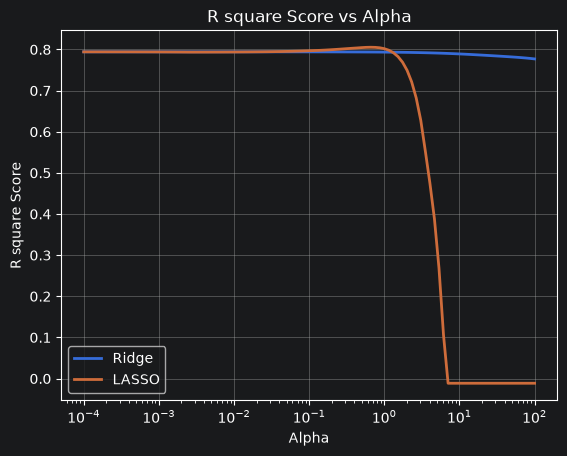

In [157]:
plt.plot(alphas,ridge_scores,label="Ridge",linewidth=2)
plt.plot(alphas,lasso_scores,label="LASSO",linewidth=2)

plt.xscale("log")
plt.xlabel("Alpha")
plt.ylabel("R square Score")
plt.title("R square Score vs Alpha")

plt.legend()
plt.grid(True)

plt.show()

Answer G> Best Alpha Identification:
   * The optimal alpha for Ridge is 0.0001 with a top R square score of 0.7942
   * The optimal alpha for LASSO is 0.6579332246575682 with a top R square of 0.8054